# Vibe 21 — Hourly Demand Surrogate Training Walkthrough

Control-oriented **hourly facility electric demand** surrogate for Building 100 Twin DR what-ifs.

| | |
| --- | --- |
| **Status** | `CANDIDATE` |
| **Provenance** | `ENERGYPLUS_SIMULATED` (native EnergyPlus farm) |
| **Primary target** | `facility_kw` |
| **Explainers** | 29 features in `FEATURE_COLS` (weather, DR knobs, lags, strategy/phase one-hots) |

**Important — this is not a full year of data.** The farm is **40 stratified calendar days** × multiple DR strategies ≈ **4,560 hourly rows** (hour-ending 1–24). Weather spans cool→extreme days from the Twin AMY EPW, but it is **not** 8,760 consecutive annual hours.

Models compared (each with `RandomizedSearchCV` GroupKFold hyperparams where applicable):

- Linear: Ridge, ElasticNet  
- Trees: RandomForest, **ExtraTrees**  
- Boosting: **GradientBoostingRegressor** (classic sklearn), **HistGradientBoostingRegressor** (fast histogram HGB)  
- Ensembles: **VotingRegressor**, **StackingRegressor** (Ridge meta)  
- Champion family gets an **extra refine** hyperparam search before shipping

## 0 — Paths & imports

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
    VotingRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

REPO = Path("..").resolve()
if not (REPO / "ml" / "feature_compile_dm.py").exists():
    REPO = Path.cwd().resolve()
    if not (REPO / "ml" / "feature_compile_dm.py").exists():
        REPO = Path.cwd().parent.resolve()

ML = REPO / "ml"
sys.path.insert(0, str(ML))

from feature_compile_dm import FEATURE_COLS, TARGET_COL, GROUP_COL, compile_features, matrix_xy, peak_mask
from train_demand_hourly import load_farm_frame, _metrics

WS = Path.home() / "wattlab_workspace"
PARQUET = WS / "reports" / "dm_hourly_farm" / "dm_hourly_rows.parquet"
MODEL = WS / "models" / "demand_hourly_v1.joblib"
CARD = WS / "models" / "demand_hourly_v1_model_card.json"
TUNING = WS / "models" / "demand_hourly_v1_tuning.json"
FIGS = REPO / "vibe21_agent_spec" / "figures" / "dm_hourly"

print("REPO     :", REPO)
print("Parquet  :", PARQUET, "exists=", PARQUET.exists())
print("Model    :", MODEL, "exists=", MODEL.exists())
assert PARQUET.exists(), "Farm parquet missing — run dm_hourly_farm.py first"

REPO     : C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_21
Parquet  : C:\Users\ben\wattlab_workspace\reports\dm_hourly_farm\dm_hourly_rows.parquet exists= True
Model    : C:\Users\ben\wattlab_workspace\models\demand_hourly_v1.joblib exists= True


## 1 — Dataset overview (hourly, but not 365 days)

Each row = **one hour-ending** of a single-day EnergyPlus DR simulation.

In [2]:
df = load_farm_frame(PARQUET)

print("=" * 64)
print("DATASET OVERVIEW")
print("=" * 64)
print(f"Total hourly rows           : {len(df):,}")
print(f"Unique farm days            : {df['day'].nunique()}   << NOT 365")
print(f"Unique simulation_ids       : {df['simulation_id'].nunique()}")
print(f"Hour-ending range           : {int(df['hour_ending'].min())} – {int(df['hour_ending'].max())}")
print(f"Hours per simulation (mode) : {int(df.groupby('simulation_id').size().mode().iloc[0])}")
print(f"Time interval               : 1 hour (hour-ending convention)")
print(f"Full-year hourly would be   : 8,760 rows — this farm is a stratified multi-day DR panel")
print()
print("Provenance:")
print(df["provenance_source"].value_counts().to_string())
print()
print("Strategies:")
print(df["strategy_id"].value_counts().sort_index().to_string())
print()
print("Phases:")
print(df["phase"].value_counts().to_string())
print()
print("Target facility_kw (kW) describe:")
print(df["facility_kw"].describe().round(2).to_string())
df.head(3)

DATASET OVERVIEW
Total hourly rows           : 4,560
Unique farm days            : 40   << NOT 365
Unique simulation_ids       : 190
Hour-ending range           : 1 – 24
Hours per simulation (mode) : 24
Time interval               : 1 hour (hour-ending convention)
Full-year hourly would be   : 8,760 rows — this farm is a stratified multi-day DR panel

Provenance:
provenance_source
ENERGYPLUS_SIMULATED    4560

Strategies:
strategy_id
baseline               960
chiller_off            960
deadband_10f           960
hvac_off               240
loadshed_p5f           240
precool_chiller_off    240
precool_shift          960

Phases:
phase
baseline    3500
precool      300
recovery     300
relax        240
shed         220

Target facility_kw (kW) describe:
count    4560.00
mean      169.70
std       123.01
min        38.04
25%        48.45
50%       177.95
75%       245.87
max       484.24


,schema_version,simulation_id,twin_run_id,day,hour_ending,dow,oat_c,rh_pct,ghi,occupied,...,chw_avail,fan_avail,facility_kw,cooling_kw,max_zone_temp_c,unmet_hours_flag,provenance_source,idf_sha256,epw,mode
0,vibe21.dm_hourly_row.v1,ops11_2025-06-23_baseline,geo_b100_dual_ahu_shape_ops11,2025-06-23,1,Monday,33.6,49.0,204.0,False,...,1.0,1.0,48.449,None,None,False,ENERGYPLUS_SIMULATED,df74c04ecfb80afe04fc87136f955eb6de0e6ce8754bdd...,amy.epw,baseline
1,vibe21.dm_hourly_row.v1,ops11_2025-06-23_baseline,geo_b100_dual_ahu_shape_ops11,2025-06-23,2,Monday,32.3,53.0,57.0,False,...,1.0,1.0,48.449,None,None,False,ENERGYPLUS_SIMULATED,df74c04ecfb80afe04fc87136f955eb6de0e6ce8754bdd...,amy.epw,baseline
2,vibe21.dm_hourly_row.v1,ops11_2025-06-23_baseline,geo_b100_dual_ahu_shape_ops11,2025-06-23,3,Monday,31.3,57.0,0.0,False,...,1.0,1.0,48.449,None,None,False,ENERGYPLUS_SIMULATED,df74c04ecfb80afe04fc87136f955eb6de0e6ce8754bdd...,amy.epw,baseline


## 2 — Target variable(s) and explainers (features)

### Target (what the trainer predicts)

| Column | Unit | Meaning |
| --- | --- | --- |
| **`facility_kw`** | kW | Whole-building hourly electric demand from EnergyPlus |

Auxiliary physics columns exist in the farm (`cooling_kw`, `max_zone_temp_c`, `unmet_hours_flag`) but are **not** model targets in `demand_hourly_v1` — only `facility_kw` is trained / served by Flask.

### Explainers / features (`FEATURE_COLS`, 29)

These are the X columns the surrogate uses at train and at Unity→Flask inference.

In [3]:
EXPLAINER_GROUPS = {
    "time / occupancy": ["hour_ending", "occupied", "is_weekend"],
    "weather": ["oat_c", "rh_pct", "ghi", "oat_lag1"],
    "DR window + action knobs": [
        "in_dr_window", "precool_f", "relax_clg_f", "relax_htg_f",
        "dat_delta_f", "chw_avail", "fan_avail", "deadband_target_f",
    ],
    "same-day demand lags (no future leakage)": ["facility_kw_lag1", "facility_kw_lag2"],
    "phase one-hots": [c for c in FEATURE_COLS if c.startswith("phase_")],
    "strategy one-hots": [c for c in FEATURE_COLS if c.startswith("strategy_")],
}

print("TARGET_COL =", TARGET_COL)
print("GROUP_COL  =", GROUP_COL, "(GroupKFold splits by day)")
print(f"n_explainers = {len(FEATURE_COLS)}")
print()
for group, cols in EXPLAINER_GROUPS.items():
    print(f"[{group}] ({len(cols)})")
    for c in cols:
        print(f"  - {c}")
    print()

missing = [c for c in FEATURE_COLS if c not in sum(EXPLAINER_GROUPS.values(), [])]
print("Uncategorized FEATURE_COLS:", missing or "(none)")
assert set(FEATURE_COLS) == set(sum(EXPLAINER_GROUPS.values(), [])), "Feature catalog mismatch"

TARGET_COL = facility_kw
GROUP_COL  = day (GroupKFold splits by day)
n_explainers = 29

[time / occupancy] (3)
  - hour_ending
  - occupied
  - is_weekend

[weather] (4)
  - oat_c
  - rh_pct
  - ghi
  - oat_lag1

[DR window + action knobs] (8)
  - in_dr_window
  - precool_f
  - relax_clg_f
  - relax_htg_f
  - dat_delta_f
  - chw_avail
  - fan_avail
  - deadband_target_f

[same-day demand lags (no future leakage)] (2)
  - facility_kw_lag1
  - facility_kw_lag2

[phase one-hots] (5)
  - phase_baseline
  - phase_precool
  - phase_relax
  - phase_shed
  - phase_recovery

[strategy one-hots] (7)
  - strategy_baseline
  - strategy_precool_shift
  - strategy_deadband_10f
  - strategy_chiller_off
  - strategy_loadshed_p5f
  - strategy_hvac_off
  - strategy_precool_chiller_off

Uncategorized FEATURE_COLS: (none)


## 3 — Compile feature matrix

In [4]:
feat = compile_features(df)
X, y, groups, cols = matrix_xy(df)
pk = peak_mask(df)

print(f"X shape        : {X.shape}")
print(f"y shape        : {y.shape}  target={TARGET_COL}")
print(f"unique days    : {len(np.unique(groups))}")
print(f"peak-mask rows : {int(pk.sum()):,} (hour_ending 15–16)")
print()
display(feat[cols + [TARGET_COL]].head(5))

X shape        : (4560, 29)
y shape        : (4560,)  target=facility_kw
unique days    : 40
peak-mask rows : 380 (hour_ending 15–16)



,hour_ending,oat_c,rh_pct,ghi,occupied,in_dr_window,precool_f,relax_clg_f,relax_htg_f,dat_delta_f,...,phase_recovery,strategy_baseline,strategy_precool_shift,strategy_deadband_10f,strategy_chiller_off,strategy_loadshed_p5f,strategy_hvac_off,strategy_precool_chiller_off,is_weekend,facility_kw
0,1,-3.8,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,56.401
1,1,-3.8,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,56.401
2,1,-3.8,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,56.401
3,1,-3.8,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,56.401
4,2,-4.4,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,51.811


## 4 — Model bake-off + hyperparameter search

Each family below gets **GroupKFold `RandomizedSearchCV`** (except persistence).  
Then we build **Voting** + **Stacking** ensembles from the tuned tree/boosting members.  
Finally the best single-model family gets a **champion refine** search (extra hyperparam budget) — same recipe as `ml/tune_demand_hourly.py`.

In [5]:
from sklearn.metrics import make_scorer

RANDOM_STATE = 21
N_ITER = 18          # per family (notebook-speed; CLI default is 40)
REFINE_ITER = 40     # extra budget for best single-model family
N_SPLITS = min(5, max(2, len(np.unique(groups))))
gkf = GroupKFold(n_splits=N_SPLITS)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
lag_i = cols.index("facility_kw_lag1")

SEARCH = {
    "ridge": (Ridge(), {"alpha": np.logspace(-3, 3, 16).tolist()}),
    "rf": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [80, 120, 200], "max_depth": [6, 10, 16, None], "min_samples_leaf": [1, 2, 4, 8]},
    ),
    "extra_trees": (
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [80, 120, 200], "max_depth": [6, 10, 16, None], "min_samples_leaf": [1, 2, 4, 8]},
    ),
    "gbr": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {"learning_rate": [0.05, 0.08, 0.12], "max_depth": [2, 3, 5], "n_estimators": [100, 200], "min_samples_leaf": [10, 20]},
    ),
    "hgb": (
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        {"learning_rate": [0.05, 0.08, 0.12], "max_depth": [3, 5, 8, None], "max_iter": [100, 200, 400], "min_samples_leaf": [10, 20, 40]},
    ),
}

def clone_fit(est, params):
    m = est.__class__(**params)
    if "random_state" in m.get_params():
        m.set_params(random_state=RANDOM_STATE)
    if "n_jobs" in m.get_params():
        m.set_params(n_jobs=-1)
    return m

def oof_predict(factory):
    oof = np.zeros_like(y, dtype=float)
    for tr, te in gkf.split(X, y, groups):
        m = factory()
        m.fit(X[tr], y[tr])
        oof[te] = m.predict(X[te])
    return oof

# Persistence
pers_oof = np.zeros_like(y)
for _, te in gkf.split(X, y, groups):
    pers_oof[te] = X[te, lag_i]
pers_met = _metrics(y, pers_oof, pk)
print(f"persistence peak MAE={pers_met['mae_peak_14_16']:.2f} kW")

tuned, tuned_params, rows = {}, {}, []
for name, (proto, space) in SEARCH.items():
    n_combos = int(np.prod([max(len(v), 1) for v in space.values()]))
    iters = min(N_ITER, n_combos)
    print(f"tune {name} n_iter={iters} …", flush=True)
    search = RandomizedSearchCV(
        proto, space, n_iter=iters, scoring=mae_scorer, cv=gkf,
        random_state=RANDOM_STATE, n_jobs=-1, refit=True,
    )
    search.fit(X, y, groups=groups)
    tuned[name] = search.best_estimator_
    tuned_params[name] = dict(search.best_params_)
    oof = oof_predict(lambda e=search.best_estimator_, p=dict(search.best_params_): clone_fit(e, p))
    met = _metrics(y, oof, pk)
    rows.append({"family": name, "mae": met["mae"], "peak_mae": met["mae_peak_14_16"],
                 "beats_pers_peak": met["mae_peak_14_16"] < pers_met["mae_peak_14_16"],
                 "best_params": search.best_params_})
    print(f"  {name}: MAE={met['mae']:.2f}  peak={met['mae_peak_14_16']:.2f}  params={search.best_params_}")

# Ensembles
members = [k for k in ("hgb", "gbr", "rf", "extra_trees") if k in tuned]
print(f"ensembles over {members} …", flush=True)
oof_v = oof_predict(lambda: VotingRegressor(
    estimators=[(k, clone_fit(tuned[k], tuned_params[k])) for k in members]
))
met_v = _metrics(y, oof_v, pk)
rows.append({"family": "voting", "mae": met_v["mae"], "peak_mae": met_v["mae_peak_14_16"],
             "beats_pers_peak": met_v["mae_peak_14_16"] < pers_met["mae_peak_14_16"],
             "best_params": {"members": members}})
print(f"  voting: MAE={met_v['mae']:.2f}  peak={met_v['mae_peak_14_16']:.2f}")

oof_s = oof_predict(lambda: StackingRegressor(
    estimators=[(k, clone_fit(tuned[k], tuned_params[k])) for k in members],
    final_estimator=Ridge(alpha=1.0), cv=min(3, N_SPLITS), n_jobs=-1,
))
met_s = _metrics(y, oof_s, pk)
rows.append({"family": "stacking", "mae": met_s["mae"], "peak_mae": met_s["mae_peak_14_16"],
             "beats_pers_peak": met_s["mae_peak_14_16"] < pers_met["mae_peak_14_16"],
             "best_params": {"members": members, "meta": "Ridge"}})
print(f"  stacking: MAE={met_s['mae']:.2f}  peak={met_s['mae_peak_14_16']:.2f}")

# Champion refine on best single-model family
single = [r for r in rows if r["family"] in SEARCH]
refine_family = min(single, key=lambda r: r["peak_mae"])["family"]
proto, space = SEARCH[refine_family]
iters = min(REFINE_ITER, int(np.prod([max(len(v), 1) for v in space.values()])))
print(f"champion refine {refine_family} n_iter={iters} …", flush=True)
search = RandomizedSearchCV(
    proto, space, n_iter=iters, scoring=mae_scorer, cv=gkf,
    random_state=RANDOM_STATE + 7, n_jobs=-1, refit=True,
)
search.fit(X, y, groups=groups)
tuned[refine_family] = search.best_estimator_
tuned_params[refine_family] = dict(search.best_params_)
oof = oof_predict(lambda: clone_fit(search.best_estimator_, search.best_params_))
met = _metrics(y, oof, pk)
rows = [r for r in rows if r["family"] != refine_family]
rows.append({"family": refine_family, "mae": met["mae"], "peak_mae": met["mae_peak_14_16"],
             "beats_pers_peak": met["mae_peak_14_16"] < pers_met["mae_peak_14_16"],
             "best_params": search.best_params_, "refined": True})
print(f"  refined {refine_family}: peak={met['mae_peak_14_16']:.2f}  params={search.best_params_}")

board = pd.DataFrame(rows).sort_values("peak_mae").reset_index(drop=True)
if "refined" not in board.columns:
    board["refined"] = False
print()
print("LEADERBOARD (sorted by peak MAE 14-16):")
display(board[["family", "mae", "peak_mae", "beats_pers_peak", "refined"]].round(2))
print(f"persistence peak MAE = {pers_met['mae_peak_14_16']:.2f} kW")
champ_row = board.iloc[0]
print(f"NOTEBOOK CHAMPION (by peak): {champ_row['family']}  peak_mae={champ_row['peak_mae']:.2f}")

persistence peak MAE=21.01 kW
tune ridge n_iter=16 …


  ridge: MAE=27.11  peak=27.79  params={'alpha': 1000.0}
tune rf n_iter=18 …


  rf: MAE=17.27  peak=16.61  params={'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 10}
tune extra_trees n_iter=18 …


  extra_trees: MAE=14.54  peak=11.46  params={'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 10}
tune gbr n_iter=18 …


  gbr: MAE=17.86  peak=15.22  params={'n_estimators': 100, 'min_samples_leaf': 10, 'max_depth': 5, 'learning_rate': 0.12}
tune hgb n_iter=18 …


...

  voting: MAE=15.99  peak=14.11


  stacking: MAE=15.14  peak=12.62
champion refine extra_trees n_iter=40 …


  refined extra_trees: peak=11.46  params={'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 10}

LEADERBOARD (sorted by peak MAE 14-16):


,family,mae,peak_mae,beats_pers_peak,refined
0,extra_trees,14.54,11.46,True,True
1,stacking,15.14,12.62,True,NaN
2,voting,15.99,14.11,True,NaN
3,gbr,17.86,15.22,True,NaN
4,hgb,17.21,16.50,True,NaN
5,rf,17.27,16.61,True,NaN
6,ridge,27.11,27.79,False,NaN


persistence peak MAE = 21.01 kW
NOTEBOOK CHAMPION (by peak): extra_trees  peak_mae=11.46


### Fit notebook champion on all rows

In [6]:
champ_name = board.iloc[0]["family"]
if champ_name in ("voting", "stacking"):
    # Prefer refined single model for a simple deployable estimator in-notebook;
    # shipped artifact comes from CLI tune which can serialize ensembles.
    champ_name = refine_family
    print(f"Ensemble won peak board; fitting refined single model '{champ_name}' for notebook demo artifact.")

champion = clone_fit(tuned[champ_name], tuned_params[champ_name])
champion.fit(X, y)
print(f"Fitted {champ_name} on all {len(y):,} rows")
print(f"In-sample MAE: {mean_absolute_error(y, champion.predict(X)):.2f} kW")
print("Best params:", tuned_params[champ_name])

Fitted extra_trees on all 4,560 rows
In-sample MAE: 5.69 kW
Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 10}


## 5 — Plots

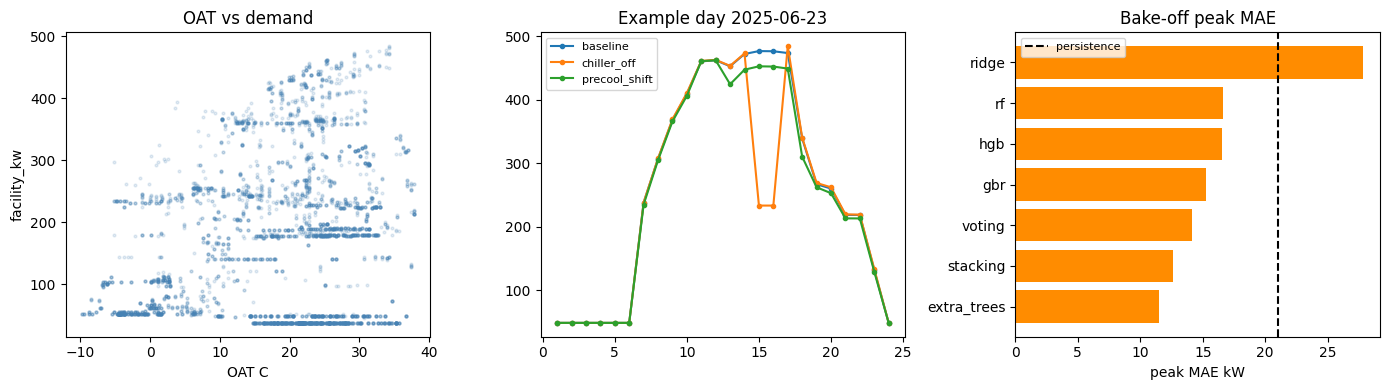

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(df["oat_c"], df["facility_kw"], s=4, alpha=0.15, c="steelblue")
axes[0].set_xlabel("OAT C"); axes[0].set_ylabel("facility_kw"); axes[0].set_title("OAT vs demand")

sample_day = df["day"].value_counts().index[0]
sub = df[(df["day"] == sample_day) & (df["strategy_id"].isin(["baseline", "precool_shift", "chiller_off"]))]
for sid, g in sub.groupby("strategy_id"):
    g = g.sort_values("hour_ending")
    axes[1].plot(g["hour_ending"], g["facility_kw"], marker="o", ms=3, label=sid)
axes[1].set_title(f"Example day {sample_day}"); axes[1].legend(fontsize=8)

axes[2].barh(board["family"], board["peak_mae"], color="darkorange")
axes[2].axvline(pers_met["mae_peak_14_16"], color="k", ls="--", label="persistence")
axes[2].set_xlabel("peak MAE kW"); axes[2].set_title("Bake-off peak MAE"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Shipped writeup figures

fig_leaderboard.png -> True


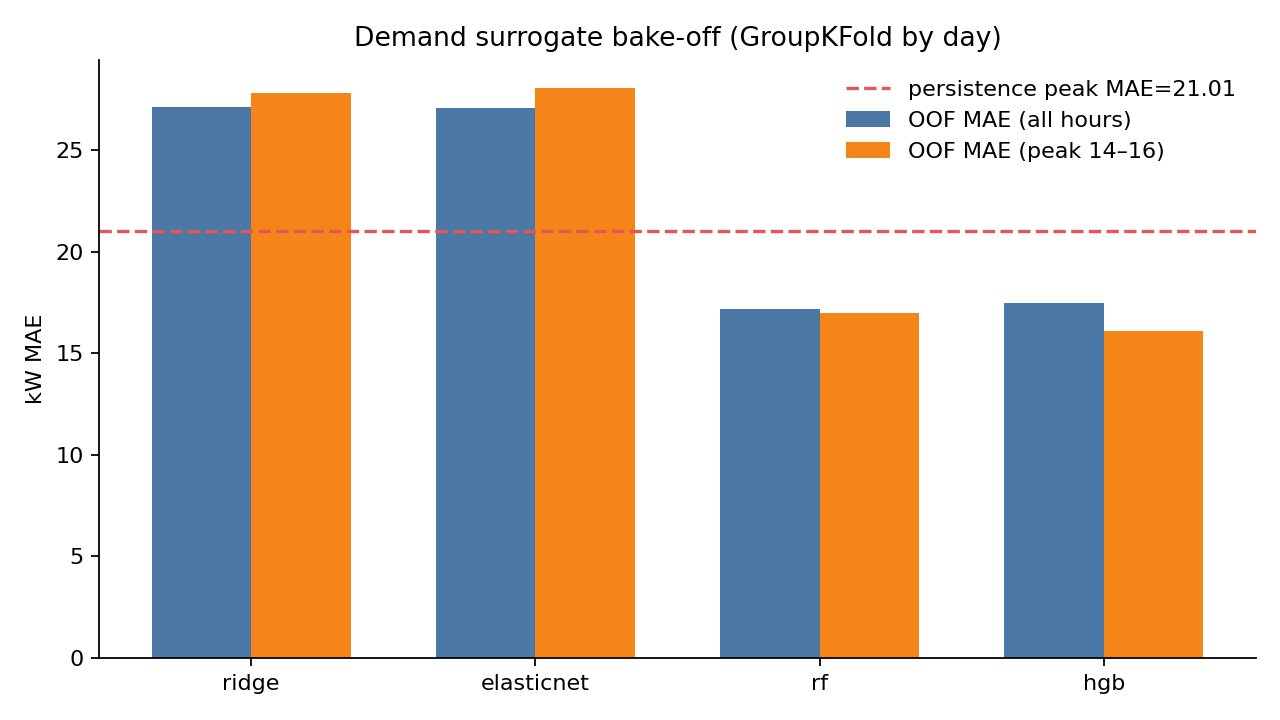

fig_strategy_peak.png -> True


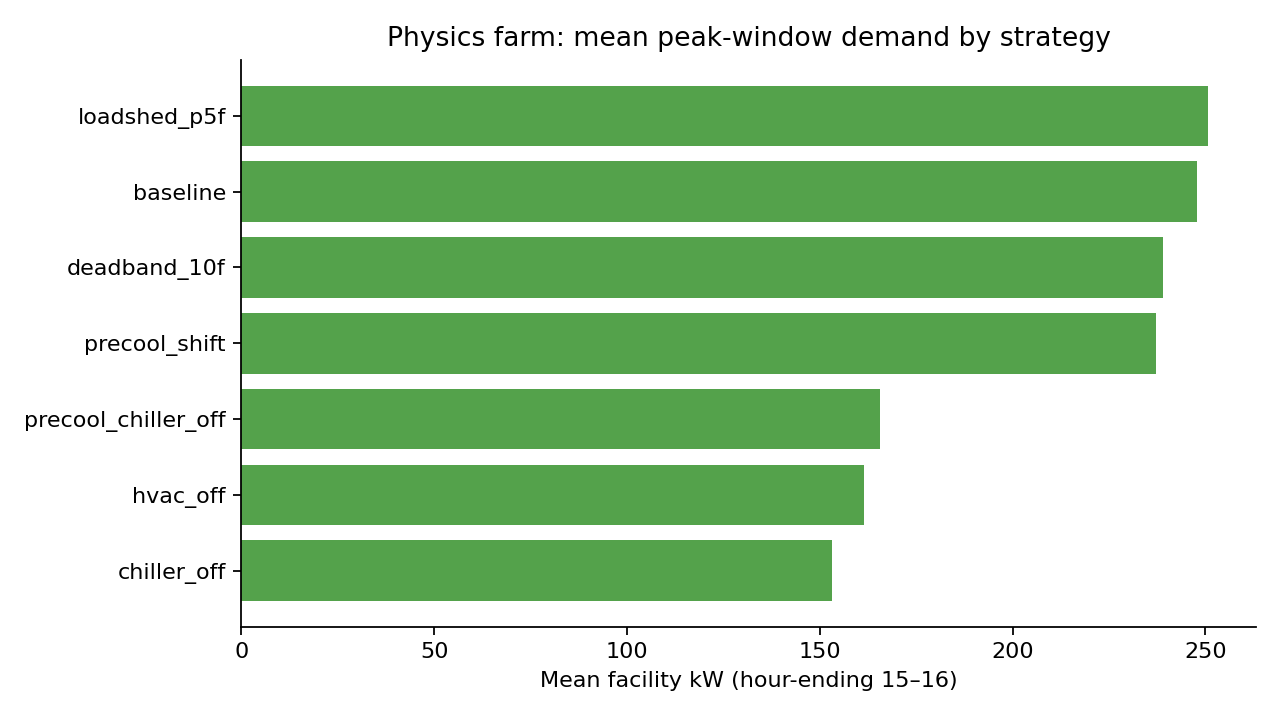

fig_oat_vs_kw.png -> True


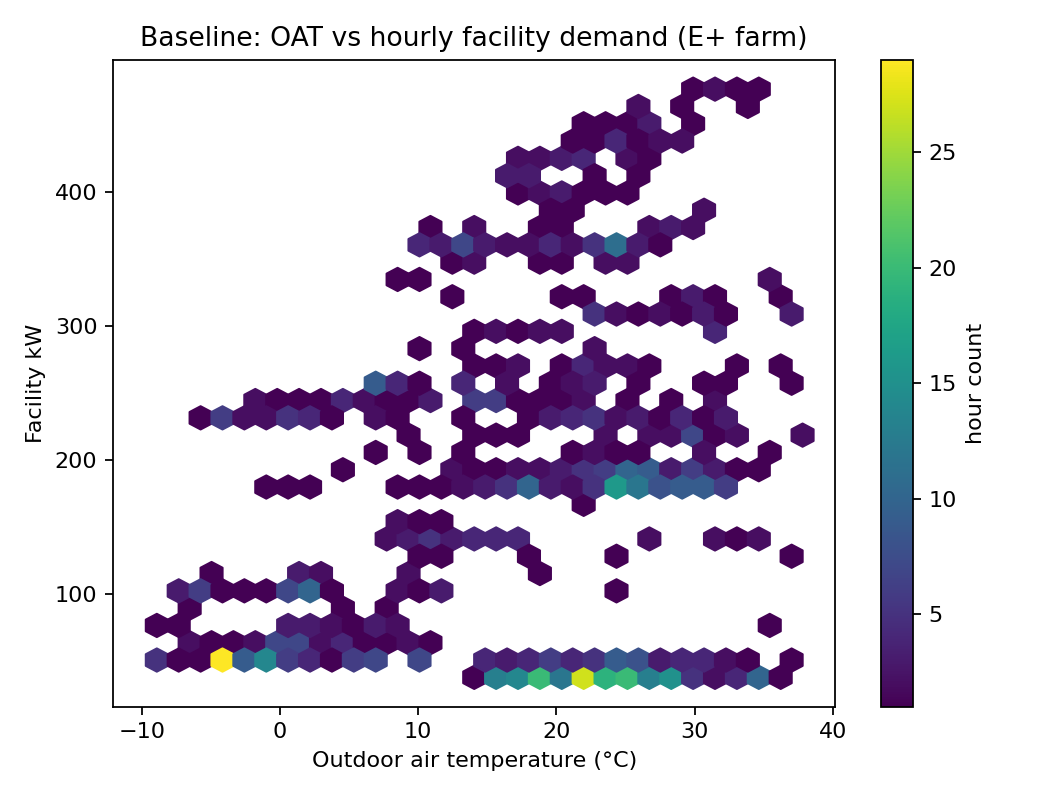

fig_example_day.png -> True


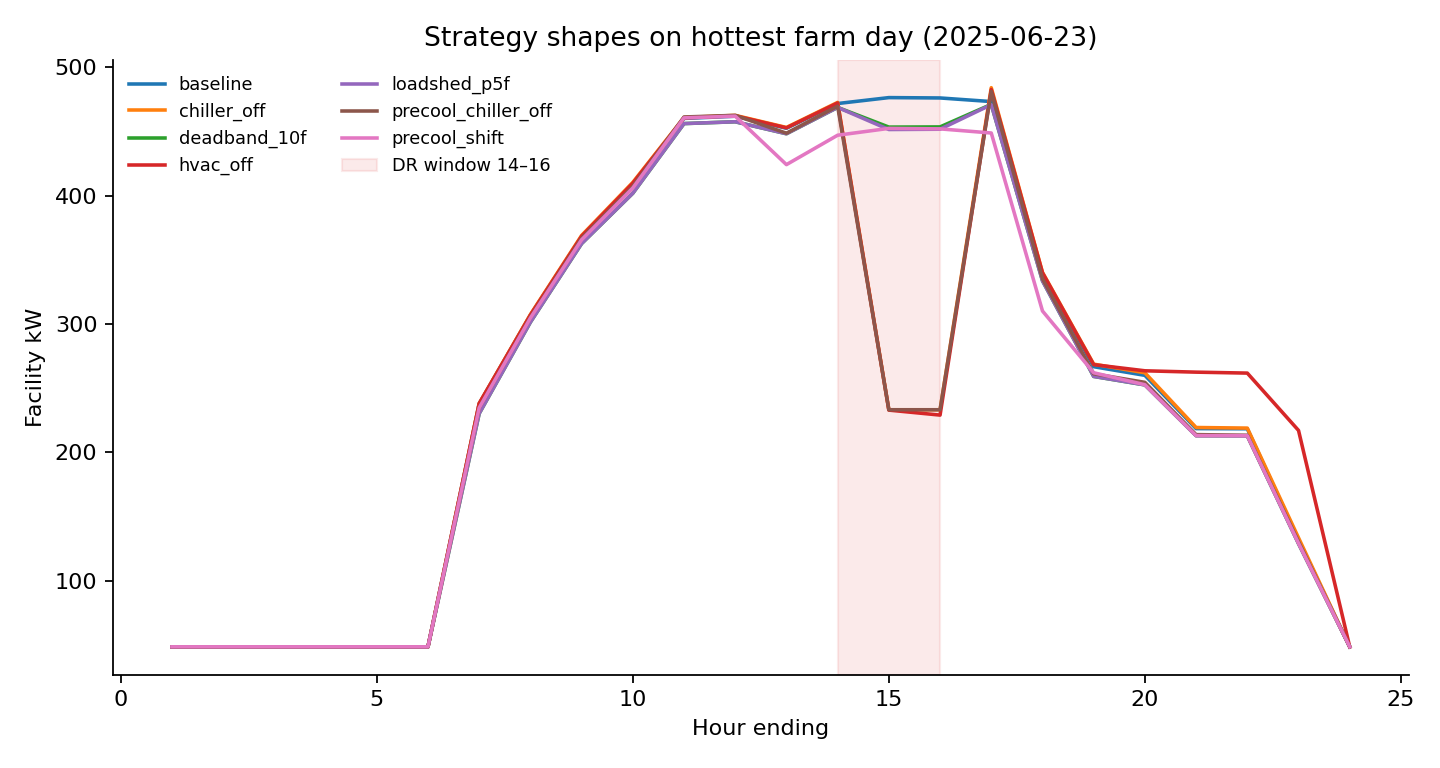

In [8]:
for name in ("fig_leaderboard.png", "fig_strategy_peak.png", "fig_oat_vs_kw.png", "fig_example_day.png"):
    p = FIGS / name
    print(name, "->", p.exists())
    if p.exists():
        display(Image(filename=str(p)))

## 6 — Shipped joblib / model card (from CLI tune)

In [9]:
if TUNING.exists():
    tuning = json.loads(TUNING.read_text(encoding="utf-8"))
    print("CLI tuning champion:", tuning.get("champion"))
    print("CLI best_params:", json.dumps(tuning.get("best_params"), indent=2)[:800])
    lb = tuning.get("leaderboard") or []
    if lb:
        display(pd.DataFrame([
            {"family": e["family"], **e.get("oof_metrics", {}), "refined": e.get("refined", False)}
            for e in lb
        ]).sort_values("mae_peak_14_16").round(2))
else:
    print("No CLI tuning JSON yet — run: python vibe_code_apps_21/ml/tune_demand_hourly.py")

if CARD.exists():
    card = json.loads(CARD.read_text(encoding="utf-8"))
    print("targets:", card.get("targets"))
    print("status:", card.get("status"), "source:", card.get("training_source") or card.get("provenance_source"))
    print("n_rows:", card.get("n_rows"), "n_days:", card.get("n_days"))

CLI tuning champion: extra_trees
CLI best_params: {
  "n_estimators": 200,
  "min_samples_leaf": 1,
  "max_depth": 10
}


,family,rmse,mae,rmse_peak_14_16,mae_peak_14_16,refined
5,extra_trees,26.82,14.54,22.37,11.46,True
7,stacking,26.39,15.08,22.00,12.77,True
6,voting,28.36,15.94,24.07,14.36,True
4,hgb,29.54,17.44,24.18,16.08,False
3,gbr,29.45,17.40,25.47,16.53,False
2,rf,33.19,17.27,31.54,16.61,False
0,ridge,44.41,27.11,50.11,27.79,False
1,elasticnet,44.78,27.15,52.92,28.80,False


targets: ['facility_kw']
status: CANDIDATE source: ENERGYPLUS_SIMULATED
n_rows: 4560 n_days: 40


## 7 — Flask + Unity interaction

```
EnergyPlus farm (40 days x strategies, hourly facility_kw)
        |
        v
tune_demand_hourly.py  (Ridge/RF/ExtraTrees/GBR/HGB + Voting/Stacking + champion refine)
        |
        v
~/wattlab_workspace/models/demand_hourly_v1.joblib
        |
        v
Flask POST /api/v1/predict/demand_hourly   (maps Unity JSON -> FEATURE_COLS explainers)
        |
        v
Unity DemandApiClient / DRControlPanel   (scrubbers or timed 2h DR playback)
        |
        v
PlantVisualController + zone/AHU DEMO temps + machine audio
```

Unity never loads the joblib. It sends explainers (OAT, RH, hour, strategy, knobs, lags) and displays predicted **`facility_kw`**.

In [10]:
row = {c: 0.0 for c in FEATURE_COLS}
row.update({
    "hour_ending": 15, "oat_c": 34.0, "rh_pct": 55.0, "ghi": 700.0, "occupied": 1.0,
    "in_dr_window": 1.0, "chw_avail": 0.0, "fan_avail": 1.0,
    "facility_kw_lag1": 240.0, "facility_kw_lag2": 235.0, "oat_lag1": 33.0,
    "phase_shed": 1.0, "strategy_chiller_off": 1.0,
})
x = np.array([[row[c] for c in FEATURE_COLS]], dtype=float)
print(f"Demo predict chiller_off @ HE15: {float(champion.predict(x)[0]):.1f} kW")

Demo predict chiller_off @ HE15: 244.5 kW


## Takeaways

- **Not a year of hourly data** — 40 stratified DR farm days, 4,560 rows, 1-hour interval.  
- **Target:** `facility_kw`. **Explainers:** 29 `FEATURE_COLS` (weather, knobs, lags, strategy/phase).  
- Bake-off includes ExtraTrees, GradientBoosting, HGB, RF, linear models, Voting & Stacking.  
- Best single-model family gets an extra hyperparam refine; CLI `tune_demand_hourly.py` ships the overall peak-MAE champion.